In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WINDOW_SIZE  = 200
NUM_CHANNELS = 1
CHANNELS     = ['voltage']
CLASS_NAMES  = ['squat', 'lunge', 'jump']

def load_gesture_file(filepath, label):
    """
    Each line in the file is one gesture window: 50 samples × 6 channels = 300 floats.
    Lines starting with # are comments from the Arduino sketch — skip them.
    Returns a list of (window_array, label) tuples.
    window_array shape: (WINDOW_SIZE, NUM_CHANNELS)
    """
    samples = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            values = [float(v) for v in line.split(',')]
            if len(values) == WINDOW_SIZE * NUM_CHANNELS:
                window = np.array(values).reshape(WINDOW_SIZE, NUM_CHANNELS)
                samples.append((window, label))
            else:
                print(f"  Skipped malformed row ({len(values)} values, expected {WINDOW_SIZE * NUM_CHANNELS})")
    return samples

squat_samples = load_gesture_file(r"C:\Users\allis\OneDrive\Documents\agentic-mote-python\squat_data.txt", label=0)
lunge_samples = load_gesture_file(r"C:\Users\allis\OneDrive\Documents\agentic-mote-python\lunge_data.txt", label=1)
jump_samples  = load_gesture_file(r"C:\Users\allis\OneDrive\Documents\agentic-mote-python\jump_data.txt",  label=2)

print(f"Squat windows loaded: {len(squat_samples)}")
print(f"Lunge windows loaded: {len(lunge_samples)}")
print(f"Jump windows loaded:  {len(jump_samples)}")
total = len(squat_samples) + len(lunge_samples) + len(jump_samples)
print(f"Total: {total} windows")

Squat windows loaded: 60
Lunge windows loaded: 60
Jump windows loaded:  60
Total: 180 windows


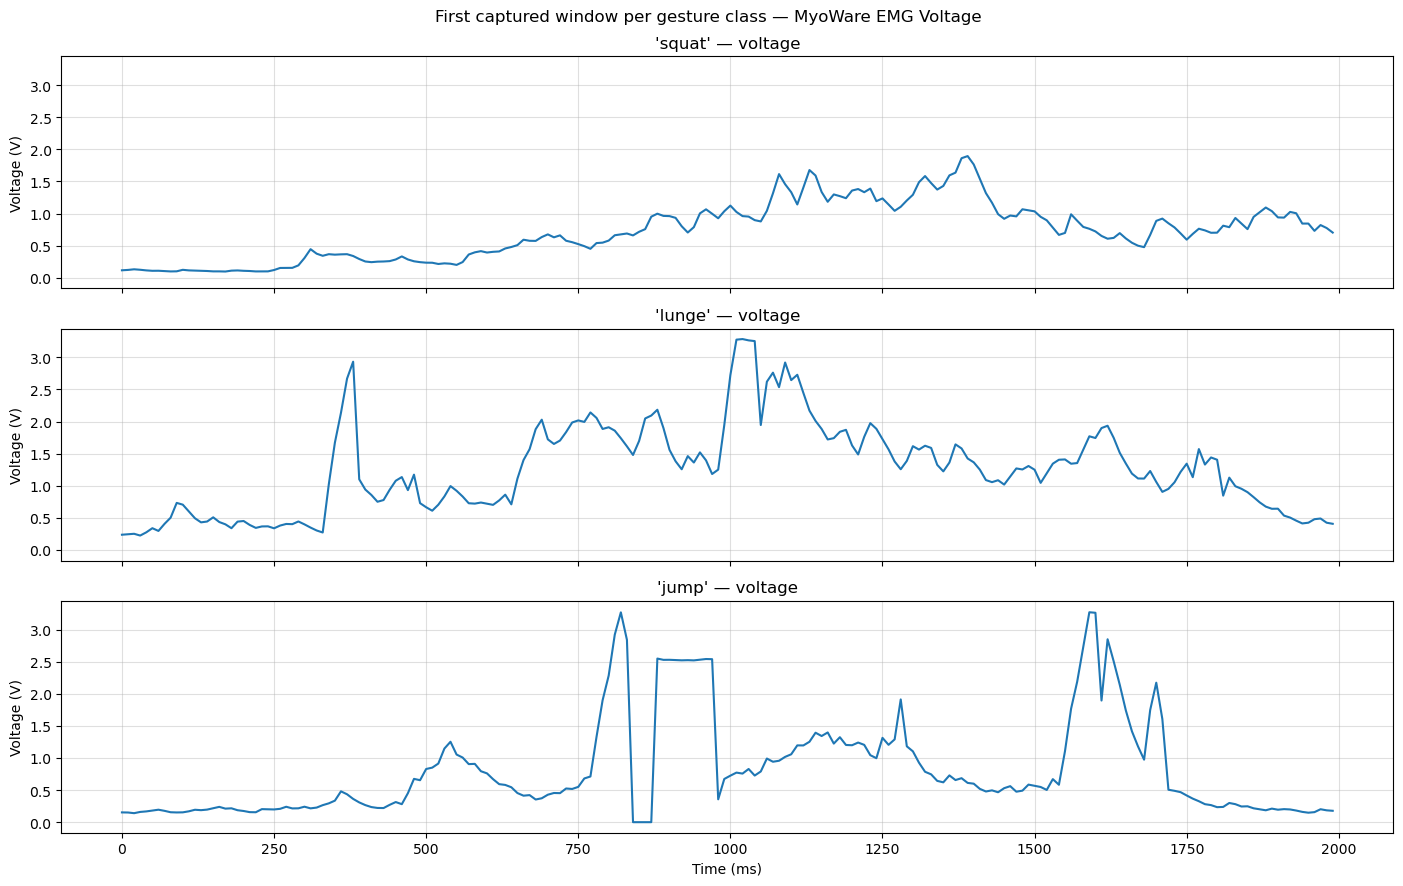

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, sharey=True)

sample_sets = [(squat_samples, 'squat'), (lunge_samples, 'lunge'), (jump_samples, 'jump')]
emg_channels = [('voltage', 0)]

for row, (samples, class_name) in enumerate(sample_sets):
    window = samples[0][0]   # grab the first collected window of this class
    t_ms = np.arange(WINDOW_SIZE) * 10  # 10 ms per sample = 100 Hz
    axes[row].plot(t_ms, window[:, ch_idx], linewidth=1.5)
    axes[row].set_title(f"'{class_name}' — {ch_name}")
    axes[row].set_ylabel("Voltage (V)")
    axes[row].grid(True, alpha=0.4)
    if row == 2:
        axes[row].set_xlabel("Time (ms)")

plt.suptitle("First captured window per gesture class — MyoWare EMG Voltage", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
def extract_features(window):
    """
    Extract 4 statistical features from one EMG window.
    Input:  window — numpy array of shape (WINDOW_SIZE, NUM_CHANNELS)
    Output: 1D numpy array of length 4, in this order:
            [mean, std, rms, p2p]
    """
    features = []
    for ch in range(NUM_CHANNELS):
        data = window[:, ch]
        mean  = np.mean(data)
        std   = np.std(data)
        rms   = np.sqrt(np.mean(data ** 2))
        p2p   = np.max(data) - np.min(data)
        features.extend([mean, std, rms, p2p])
    return np.array(features)

# Build human-readable feature names for debugging
FEATURE_NAMES = []
for ch_name in CHANNELS:
    for stat in ['mean', 'std', 'rms', 'p2p']:
        FEATURE_NAMES.append(f"{ch_name}_{stat}")

print(f"Features per window: {len(FEATURE_NAMES)}")

Features per window: 4


In [12]:
all_samples = squat_samples + lunge_samples + jump_samples

X = np.array([extract_features(window) for window, _ in all_samples])
y = np.array([label for _, label in all_samples])

print(f"Feature matrix X: shape = {X.shape}")  # (180, 4) if you collected 60 windows per class
print(f"Label vector y:   shape = {y.shape}")   # (180,)

Feature matrix X: shape = (180, 4)
Label vector y:   shape = (180,)


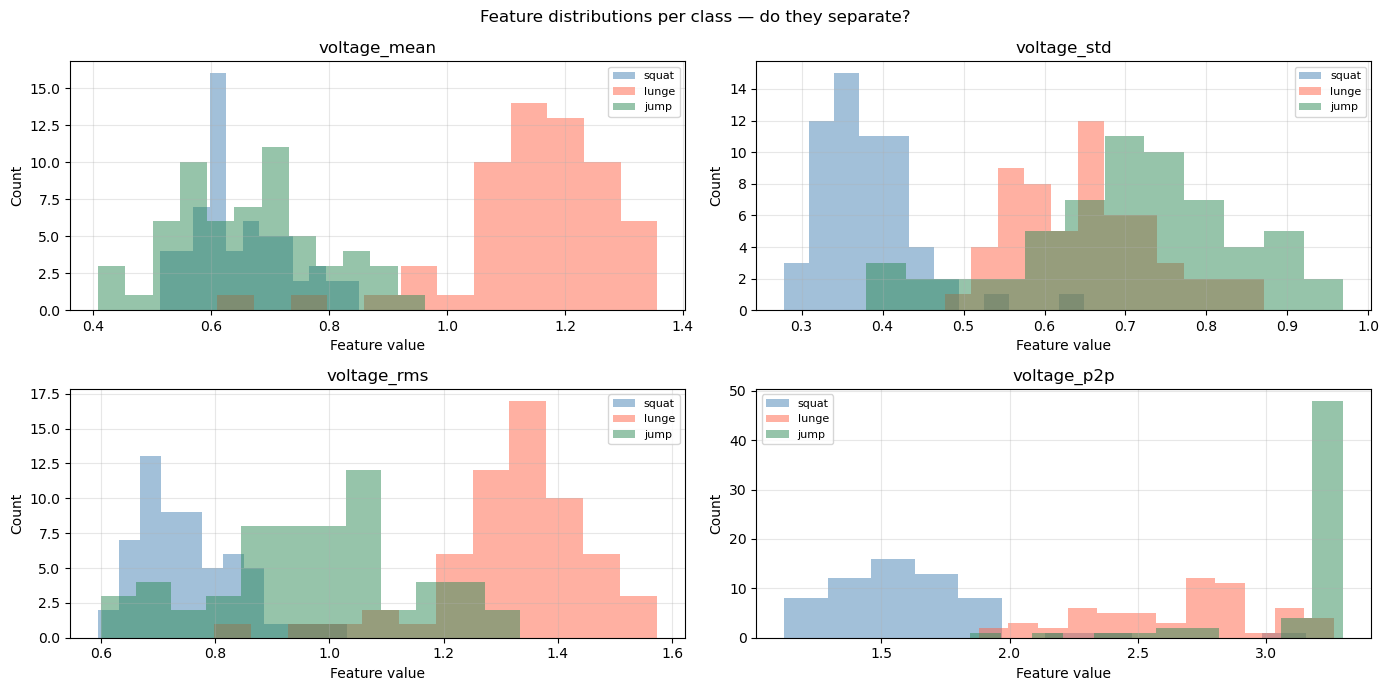

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
feature_indices_to_plot = [0, 1, 2, 3]  # std and p2p of several channels

y = np.array(y)

for ax_plot, feat_idx in zip(axes.flat, feature_indices_to_plot):
    for class_label, class_name, color in [(0,'squat','steelblue'),
                                            (1,'lunge','tomato'),
                                            (2,'jump', 'seagreen')]:
        values = X[y == class_label, feat_idx]
        ax_plot.hist(values, bins=12, alpha=0.5, label=class_name, color=color)
    ax_plot.set_title(FEATURE_NAMES[feat_idx])
    ax_plot.set_xlabel("Feature value")
    ax_plot.set_ylabel("Count")
    ax_plot.legend(fontsize=8)
    ax_plot.grid(True, alpha=0.3)

plt.suptitle("Feature distributions per class — do they separate?", fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the unscaled feature matrix first.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # hold back 20% for final evaluation
    random_state=42,      # fixed seed for reproducibility
    stratify=y            # preserve class proportions in both sets
)

# Learn normalization parameters from training data only.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)

# Apply the training transformation to the untouched test data.
X_test = scaler.transform(X_test_raw)

print(f"Training set:  {X_train.shape[0]} windows")
print(f"Test set:      {X_test.shape[0]} windows")
print()
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {np.sum(y_train == i)} train / {np.sum(y_test == i)} test")

# Show the effect of scaling on one training feature.
feat_idx = 1  # ax_std
print(f"\nFeature: {FEATURE_NAMES[feat_idx]}")
print(f"  Before scaling — mean: {X_train_raw[:, feat_idx].mean():.4f}, "
      f"std: {X_train_raw[:, feat_idx].std():.4f}")
print(f"  After scaling  — mean: {X_train[:, feat_idx].mean():.4f}, "
      f"std: {X_train[:, feat_idx].std():.4f}")

Training set:  144 windows
Test set:      36 windows

  squat: 48 train / 12 test
  lunge: 48 train / 12 test
  jump: 48 train / 12 test

Feature: voltage_std
  Before scaling — mean: 0.5683, std: 0.1701
  After scaling  — mean: 0.0000, std: 1.0000


In [18]:
print("\n--- TRAINING NORMALIZATION PARAMETERS ---")
print(f"Number of features: {len(scaler.mean_)}")
print()
print("FEATURE_MEAN =", [round(v, 6) for v in scaler.mean_])
print()
print("FEATURE_STD  =", [round(v, 6) for v in scaler.scale_])


--- TRAINING NORMALIZATION PARAMETERS ---
Number of features: 4

FEATURE_MEAN = [np.float64(0.816162), np.float64(0.568294), np.float64(1.004991), np.float64(2.449833)]

FEATURE_STD  = [np.float64(0.259587), np.float64(0.170129), np.float64(0.274593), np.float64(0.7188)]


In [19]:
manual_normalized = (X_test_raw[0] - scaler.mean_) / scaler.scale_

print("Manual calculation matches scaler.transform():",
      np.allclose(manual_normalized, X_test[0]))

Manual calculation matches scaler.transform(): True


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("=== KNN Baseline Results ===\n")
print(classification_report(y_test, y_pred_knn, target_names=CLASS_NAMES))

=== KNN Baseline Results ===

              precision    recall  f1-score   support

       squat       1.00      0.92      0.96        12
       lunge       1.00      1.00      1.00        12
        jump       0.92      1.00      0.96        12

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



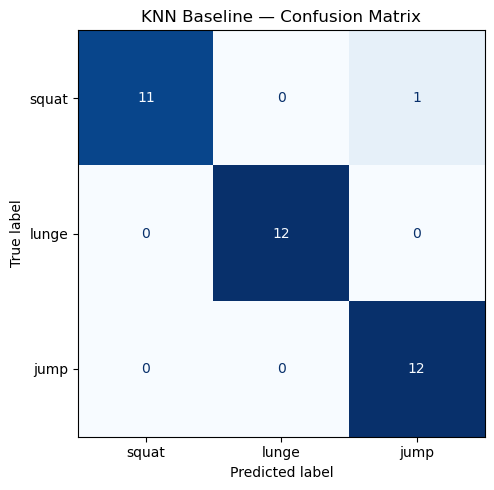

In [21]:
cm  = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("KNN Baseline — Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

NUM_FEATURES = X_train.shape[1]   # 24
NUM_CLASSES  = len(CLASS_NAMES)   # 3

model = keras.Sequential([
    layers.Input(shape=(NUM_FEATURES,)),
    layers.Dense(16, activation='relu'),   # first hidden layer: 24×16 + 16 = 400 params
    layers.Dense(8,  activation='relu'),   # second hidden layer: 16×8 + 8 = 136 params
    layers.Dense(NUM_CLASSES, activation='softmax')  # output: 8×3 + 3 = 27 params
], name='gesture_classifier')

model.summary()

Model: "gesture_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',                          # adaptive learning rate — generally works well out of the box
    loss='sparse_categorical_crossentropy',    # standard loss for integer class labels
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,               # update weights after every 16 samples
    validation_split=0.15,       # hold back 15% of training data to monitor overfitting
    verbose=1                    # print progress each epoch
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.1639 - loss: 1.2120 - val_accuracy: 0.2273 - val_loss: 1.1681
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2295 - loss: 1.1606 - val_accuracy: 0.3182 - val_loss: 1.1287
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4426 - loss: 1.1011 - val_accuracy: 0.4091 - val_loss: 1.0887
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4918 - loss: 1.0454 - val_accuracy: 0.4545 - val_loss: 1.0497
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5082 - loss: 0.9891 - val_accuracy: 0.5455 - val_loss: 1.0133
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6230 - loss: 0.9340 - val_accuracy: 0.6818 - val_loss: 0.9797
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7705 - loss: 0.8899 - val_accuracy: 0.8636 - val_loss: 0.9489
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8279 - loss: 0.8468 - val_accuracy: 0.8636 - val_loss

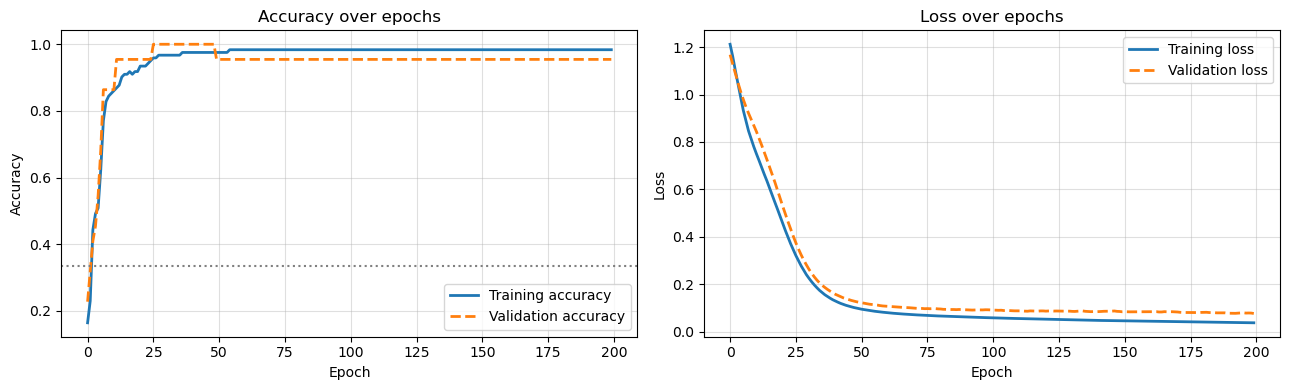

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Training accuracy',   linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy', linewidth=2, linestyle='--')
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].axhline(y=1/NUM_CLASSES, color='gray', linestyle=':', label='Chance level')

axes[1].plot(history.history['loss'],     label='Training loss',   linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation loss', linewidth=2, linestyle='--')
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Test accuracy: 97.2%
Test loss:     0.2515
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

=== Neural Network Classification Report ===

              precision    recall  f1-score   support

       squat       1.00      0.92      0.96        12
       lunge       1.00      1.00      1.00        12
        jump       0.92      1.00      0.96        12

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



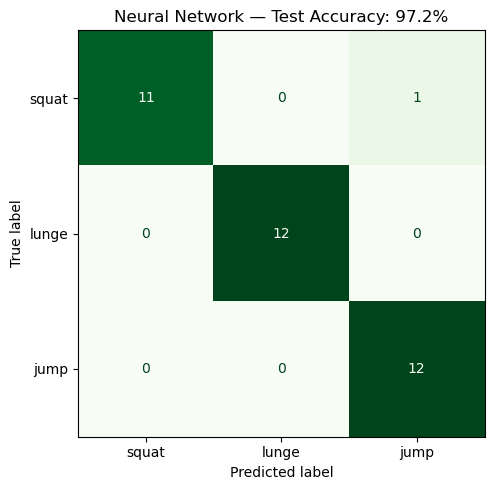

In [26]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.1f}%")
print(f"Test loss:     {test_loss:.4f}")

y_pred_nn  = np.argmax(model.predict(X_test), axis=1)
print("\n=== Neural Network Classification Report ===\n")
print(classification_report(y_test, y_pred_nn, target_names=CLASS_NAMES))

cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(cm_nn, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp_nn.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f"Neural Network — Test Accuracy: {test_acc*100:.1f}%")
plt.tight_layout()
plt.show()

In [29]:
from pathlib import Path

# Keep all generated deployment artifacts together.
MODEL_DIR = Path("./model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

converter    = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

model_size_bytes = len(tflite_model)
print(f"TFLite model size: {model_size_bytes} bytes ({model_size_bytes / 1024:.1f} KB)")
print(f"For reference — Nano 33 BLE Sense Flash: 1024 KB, RAM: 256 KB")

# Save the converted model under week-4/model/.
model_path = MODEL_DIR / "ORBIT_gesture_model.tflite"
model_path.write_bytes(tflite_model)

print(f"Saved: {model_path.resolve()}")

INFO:tensorflow:Assets written to: C:\Users\allis\AppData\Local\Temp\tmp77cdj24e\assets


INFO:tensorflow:Assets written to: C:\Users\allis\AppData\Local\Temp\tmp77cdj24e\assets


Saved artifact at 'C:\Users\allis\AppData\Local\Temp\tmp77cdj24e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1818683219232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1818703219696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1818703222336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1818703220928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1818703216704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1818703223568: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model size: 3312 bytes (3.2 KB)
For reference — Nano 33 BLE Sense Flash: 1024 KB, RAM: 256 KB
Saved: C:\Users\allis\Documents\agentic-mote-python\week-4\model\ORBIT_gesture_model.tflite


In [30]:
saved_model_exists = model_path.exists()
saved_model_size   = model_path.stat().st_size if saved_model_exists else 0

print(f"Model directory: {MODEL_DIR.resolve()}")
print(f"Model file exists: {saved_model_exists}")
print(f"Saved file size: {saved_model_size} bytes ({saved_model_size / 1024:.1f} KB)")
print(f"Size matches converted model: {saved_model_size == model_size_bytes}")

Model directory: C:\Users\allis\Documents\agentic-mote-python\week-4\model
Model file exists: True
Saved file size: 3312 bytes (3.2 KB)
Size matches converted model: True


In [31]:
# LiteRT is the modern replacement for the deprecated tf.lite.Interpreter API.
from ai_edge_litert.interpreter import Interpreter

# Load the exact model artifact saved in Section 5.2.
saved_tflite_model = model_path.read_bytes()
interpreter = Interpreter(model_path=str(model_path))

# Reserve the memory required by the model's tensors.
interpreter.allocate_tensors()

# Tensor details include each tensor's index, shape, and data type.
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_pred_tflite = []
for sample in X_test:
    # The model expects one row containing 24 normalized features.
    # reshape(1, -1) adds the batch dimension: (24,) becomes (1, 24).
    input_tensor = sample.reshape(1, -1).astype(np.float32)

    # Copy this test window into the model's input tensor.
    interpreter.set_tensor(input_details[0]['index'],
                           input_tensor)

    # Run one forward pass through the converted neural network.
    interpreter.invoke()

    # Read the three output probabilities and keep the winning class index.
    output = interpreter.get_tensor(output_details[0]['index'])
    y_pred_tflite.append(np.argmax(output))

y_pred_tflite = np.array(y_pred_tflite)
tflite_acc    = np.mean(y_pred_tflite == y_test)

print(f"Original Keras model test accuracy: {test_acc * 100:.1f}%")
print(f"TFLite model test accuracy:         {tflite_acc * 100:.1f}%")
print(f"All predictions identical:          {np.all(y_pred_tflite == y_pred_nn)}")

Original Keras model test accuracy: 97.2%
TFLite model test accuracy:         97.2%
All predictions identical:          True


In [32]:
def tflite_to_c_header(tflite_bytes, array_name='model_data', output_file=MODEL_DIR / 'ORBIT_model.h'):
    """Convert a .tflite binary into a C header with a byte array."""
    hex_values = ', '.join([f'0x{b:02x}' for b in tflite_bytes])
    header_content = f"""// Auto-generated by Week 4 AI/ML Mote Lab — do not edit manually.
// Re-run the Python conversion cell if you retrain the model.

#pragma once

const unsigned char {array_name}[] = {{
  {hex_values}
}};

const int {array_name}_len = {len(tflite_bytes)};
"""
    with open(output_file, 'w') as f:
        f.write(header_content)
    print(f"Generated: {output_file.resolve()}  ({len(tflite_bytes)} bytes)")

tflite_to_c_header(saved_tflite_model)

Generated: C:\Users\allis\Documents\agentic-mote-python\week-4\model\ORBIT_model.h  (3312 bytes)


In [33]:
def scaler_to_c_header(scaler, num_features, output_file=MODEL_DIR / 'ORBIT_normalizer.h'):
    """Generate a C header with StandardScaler mean and std parameters."""
    means = ', '.join([f'{v:.8f}f' for v in scaler.mean_])
    stds  = ', '.join([f'{v:.8f}f' for v in scaler.scale_])
    header_content = f"""// Auto-generated by Week 4 AI/ML Mote Lab — do not edit manually.
// These normalization parameters must exactly match the Python StandardScaler used during training.
// If you retrain with new data, regenerate this file.

#pragma once

const int   NUM_FEATURES        = {num_features};
const float FEATURE_MEAN[{num_features}] = {{ {means} }};
const float FEATURE_STD[{num_features}]  = {{ {stds} }};
"""
    with open(output_file, 'w') as f:
        f.write(header_content)
    print(f"Generated: {output_file.resolve()}")

scaler_to_c_header(scaler, NUM_FEATURES)

Generated: C:\Users\allis\Documents\agentic-mote-python\week-4\model\ORBIT_normalizer.h
